In [1]:
import numpy as np
import scipy
from matplotlib import pyplot as plt

import pyspec

## Test trapezoid numerical integration routine (unit test)

Test trapezoid by comparing the numerical integration result to a known integral. For example, we can use $\int_{-\infty}^\infty e^{-x^2}=\sqrt{\pi}$, performing the numerical integration over a large enough interval.

In [2]:
x = np.linspace(-10, 10, 50)
y = np.exp(-x**2)

In [3]:
integral = pyspec.integrate.trapezoid(x, y)

In [4]:
reference = np.sqrt(np.pi)

In [8]:
print(integral) 
print(reference) 
print("%5.2e" % (integral - reference))

1.772453850905516
1.7724538509055159
2.22e-16


In [7]:
# scipy test
from scipy.integrate import quad

def integrand(x):
    return np.exp(-x**2)

result, error = quad(integrand, -np.inf, np.inf)
print(result) 
print(error) 

1.7724538509055159
1.4202636780944923e-08


## Test calculating the area of a spectrum (integration test)

Test if the numerical integration routine works within the Spectrum class. For this, we'll read in a spectrum and compare the integral obtained with the trapezoid routine with the integral obtained via a different numerical method (e.g. np.trapezoid, scipy.integrate.simpson, scipy.integrate.trapezoid, etc.)

In [9]:
data = np.loadtxt(r"C:/Users/agngu/Documents/Coding/repos/py3umk/examples/metohCW_k.txt")

In [10]:
help(pyspec.Spectrum)

Help on class Spectrum in module pyspec.spectrum:

class Spectrum(builtins.object)
 |  Spectrum(x=None, y=None)
 |
 |  Implements the Spectrum class.
 |
 |  Instance variables:
 |               - x: the photon energy values.
 |               - y: the intensities.
 |               - x_units: energy units.
 |               - y_units: intensity units.
 |
 |  Methods defined here:
 |
 |  __init__(self, x=None, y=None)
 |      Initializes a spectrum.
 |
 |  __str__(self)
 |      Prints a spectrum.
 |
 |  integrate(self)
 |      Integrates the area under the spectrum.
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



In [11]:
spectrum = pyspec.Spectrum(data[:, 0], data[:, 1])

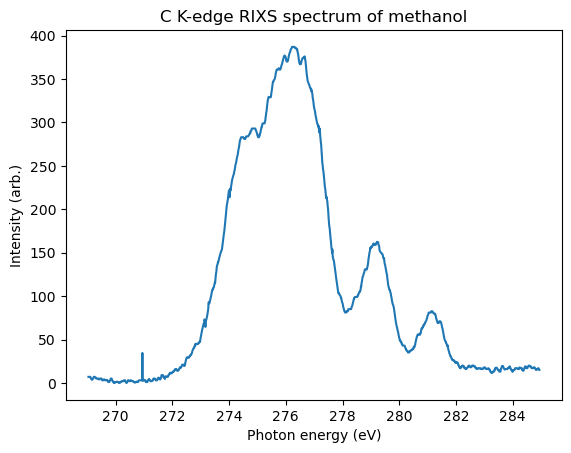

In [12]:
plt.figure()
plt.plot(spectrum.x, spectrum.y)
plt.xlabel("Photon energy (%s)" % spectrum.x_units)
plt.ylabel("Intensity (%s)" % spectrum.y_units)
plt.title("C K-edge RIXS spectrum of methanol")
plt.show()

In [13]:
area = spectrum.integrate()

In [16]:
# input data check
data[:,0] # energies
data[:,1] # intensities
help(scipy.integrate.trapezoid)

Help on function trapezoid in module scipy.integrate._quadrature:

trapezoid(y, x=None, dx=1.0, axis=-1)
    Integrate along the given axis using the composite trapezoidal rule.

    If `x` is provided, the integration happens in sequence along its
    elements - they are not sorted.

    Integrate `y` (`x`) along each 1d slice on the given axis, compute
    :math:`\int y(x) dx`.
    When `x` is specified, this integrates along the parametric curve,
    computing :math:`\int_t y(t) dt =
    \int_t y(t) \left.\frac{dx}{dt}\right|_{x=x(t)} dt`.

    Parameters
    ----------
    y : array_like
        Input array to integrate.
    x : array_like, optional
        The sample points corresponding to the `y` values. If `x` is None,
        the sample points are assumed to be evenly spaced `dx` apart. The
        default is None.
    dx : scalar, optional
        The spacing between sample points when `x` is None. The default is 1.
    axis : int, optional
        The axis along which to int

In [17]:
reference_area = scipy.integrate.trapezoid(data[:,1], data[:,0])

reference_area2 = scipy.integrate.simpson(data[:,1], data[:,0])

In [18]:
print("Absolute error:")
print("%5.2e" % (area - reference_area))
print("%5.2e" % (area - reference_area2))

Absolute error:
-1.59e-12
5.50e-02


In [19]:
print("Relative error:")
print("%7.5f %%" % ((area - reference_area)*100/reference_area))
print("%7.5f %%" % ((area - reference_area2)*100/reference_area2))

Relative error:
-0.00000 %
0.00320 %


In [20]:
print(area)

1719.488392523049


In [21]:
print(reference_area)

1719.4883925230506


In [22]:
print(reference_area2)

1719.4333620783252


In [ ]:
# Test for Spectrum 
class TestSpectrum:

    # for functions/modules use small_caption_with_underscores
    def test_trapezoid(self):
        x = np.linspace(-10, 10, 50)
        y = np.exp(-x**2)
        integral = trapezoid(x, y)
        reference = np.sqrt(np.pi)

        assert np.abs(integral - reference) < 1e-10

# then run: pytest .\test_trapezoid.py in console

In [23]:
## check only for SSOgen

In [31]:
from ssogenerator.utils import TLE